# Cassette design analysis

Analyze accepted sequence edits across optimization runs and quantify where edits accumulate relative to the C1–C4 motifs and loxP sequences.

In [1]:
# Imports and output directories
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_DIR = Path("data")
PLOTS_DIR = Path("plots")
DATA_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

OUT_DIR = Path(
    "/project2/fudenber_735/smaruj/sequence_design/"
    "ledidi_semifreddo_akita/optimizations/validation/"
    "cassette_design_multiple"
)

RUN_RECORDS_PATH = OUT_DIR / "run_records.json"

with open(RUN_RECORDS_PATH) as fh:
    rec = json.load(fh)

runs = rec["runs"]
cores = {k: (int(v[0]), int(v[1]), v[2]) for k, v in rec["cores"].items()}
motif_bp = rec["motif_bp"]
background_bp = rec["background_bp"]
CASSETTE_LEN = rec["cassette_len"]
S_START, S_TARGET = rec["s_start"], rec["s_target"]

print(f"{len(runs)} runs, lambda = {rec['config']['lam']}")
print(f"boundary score: start {S_START:+.5f} -> target {S_TARGET:+.5f}")
for label, (i, j, strand) in cores.items():
    print(f"  {label} ({strand})  bp {i}–{j-1}")


100 runs, lambda = 10.0
boundary score: start +0.07253 -> target +0.28201
  C1 (-)  bp 72–130
  C2 (+)  bp 238–296
  C3 (+)  bp 385–443
  C4 (+)  bp 535–593


## Optimization success and pooled edits

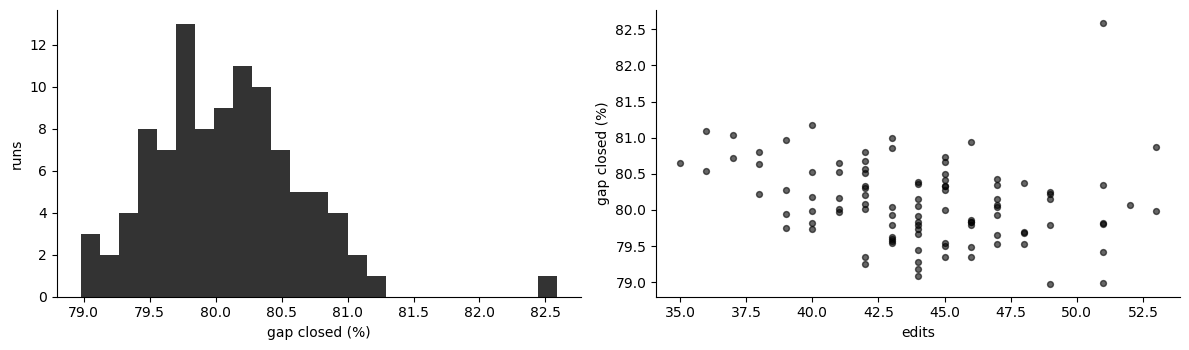

gap closed: median 80.0%, range 79.0%–82.6%
edits:      median 44, range 35–53
using all 100 runs (gap closed 79.0%–82.6%, no failures)
4,411 edits pooled (44.1 per successful run)


In [2]:
gaps = np.array([r["gap_closed"] for r in runs])
edits = np.array([r["edits"]["total"] for r in runs])

fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))
axes[0].hist(gaps * 100, bins=25, color="k", alpha=0.8)
axes[0].set_xlabel("gap closed (%)")
axes[0].set_ylabel("runs")
axes[1].scatter(edits, gaps * 100, s=18, color="k", alpha=0.6)
axes[1].set_xlabel("edits")
axes[1].set_ylabel("gap closed (%)")
for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
# fig.savefig(PLOTS_DIR / "optimization_success_overview.svg", format="svg", bbox_inches="tight")
plt.show()

print(f"gap closed: median {np.median(gaps):.1%}, range {gaps.min():.1%}–{gaps.max():.1%}")
print(f"edits:      median {np.median(edits):.0f}, range {edits.min()}–{edits.max()}")

SUCCESS_GAP = None  # no filtering — all runs converged

ok = runs if SUCCESS_GAP is None else [
    r for r in runs if r["gap_closed"] >= SUCCESS_GAP
]

print(
    f"using all {len(ok)} runs "
    f"(gap closed {min(gaps):.1%}–{max(gaps):.1%}, no failures)"
)

pos = (
    np.concatenate([np.asarray(r["edit_pos"]) for r in ok])
    if ok else np.array([])
)

tally = (
    np.bincount(pos, minlength=CASSETTE_LEN)
    if len(pos) else np.zeros(CASSETTE_LEN, int)
)

print(
    f"{len(pos):,} edits pooled "
    f"({len(pos) / max(len(ok), 1):.1f} per successful run)"
)

## Positional distribution of accepted edits

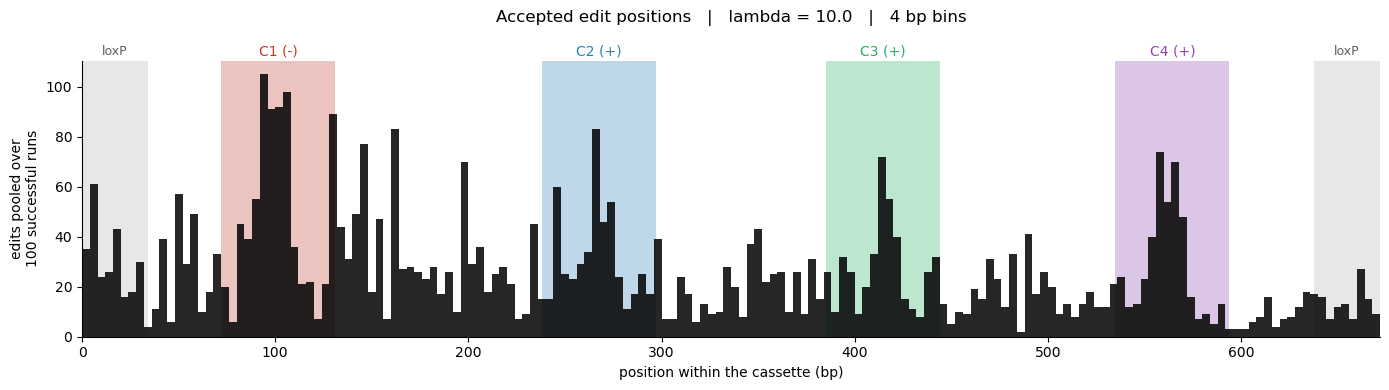

In [3]:
BIN_BP = 4
LOXP_LEN = 34
COLORS = {"C1": "#c0392b", "C2": "#2980b9", "C3": "#27ae60", "C4": "#8e44ad"}

fig, ax = plt.subplots(figsize=(14, 4))

for lo, hi in [(0, LOXP_LEN), (CASSETTE_LEN - LOXP_LEN, CASSETTE_LEN)]:
    ax.axvspan(lo, hi, color="#b4b2a9", alpha=0.30, lw=0)
    ax.text(
        (lo + hi) / 2,
        1.01,
        "loxP",
        ha="center",
        va="bottom",
        transform=ax.get_xaxis_transform(),
        color="#5f5e5a",
        fontsize=9,
    )

for label, (i, j, strand) in cores.items():
    ax.axvspan(i, j, color=COLORS[label], alpha=0.30, lw=0)
    ax.text(
        (i + j) / 2,
        1.01,
        f"{label} ({strand})",
        ha="center",
        va="bottom",
        transform=ax.get_xaxis_transform(),
        color=COLORS[label],
        fontsize=10,
    )

edges = np.arange(0, CASSETTE_LEN + BIN_BP, BIN_BP)
ax.hist(pos, bins=edges, color="k", alpha=0.85)
ax.set_xlim(0, CASSETTE_LEN)
ax.set_xlabel("position within the cassette (bp)")
ax.set_ylabel(f"edits pooled over\n{len(ok)} successful runs")
ax.spines[["top", "right"]].set_visible(False)
ax.set_title(
    f"Accepted edit positions   |   lambda = {rec['config']['lam']}   |   {BIN_BP} bp bins",
    fontsize=12,
    pad=28,
)
plt.tight_layout()
# fig.savefig(PLOTS_DIR / "edit_positions_successful.svg", format="svg", bbox_inches="tight")
plt.show()

## Edit enrichment by region

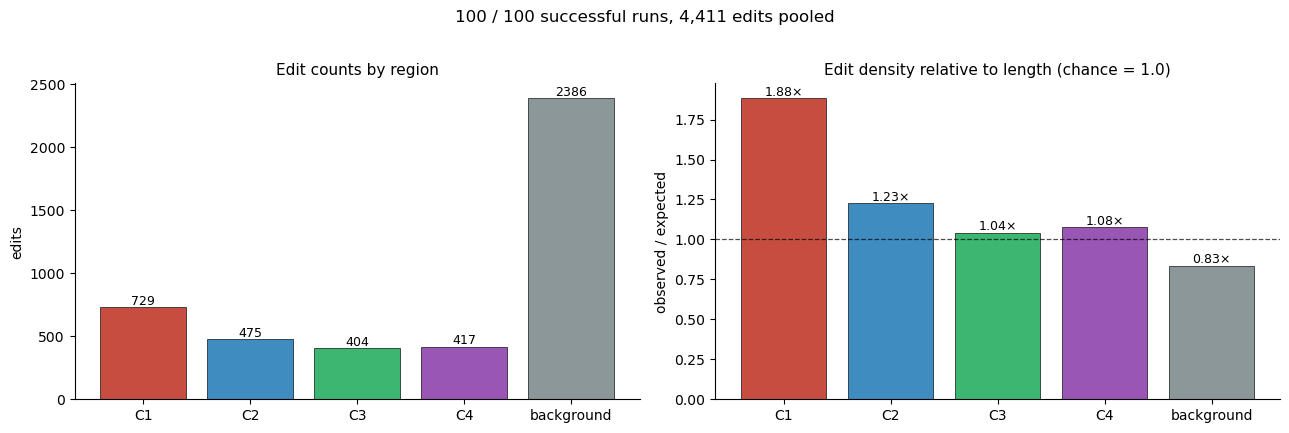

region          bp      n   obs/exp
C1              59    729      1.88
C2              59    475      1.23
C3              59    404      1.04
C4              59    417      1.08
background     436   2386      0.83


In [4]:
labels = ["C1", "C2", "C3", "C4", "background"]
region_bp = {**motif_bp, "background": background_bp}

counts = []
for k in labels:
    if k == "background":
        in_motif = sum(
            int(((pos >= i) & (pos < j)).sum())
            for i, j, _ in cores.values()
        )
        counts.append(len(pos) - in_motif)
    else:
        i, j, _ = cores[k]
        counts.append(int(((pos >= i) & (pos < j)).sum()))

chance = np.array([region_bp[k] / CASSETTE_LEN for k in labels])
obs_exp = (
    np.array(counts) / (len(pos) * chance)
    if len(pos)
    else np.full(5, np.nan)
)
bar_c = [COLORS.get(k, "#7f8c8d") for k in labels]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))

axes[0].bar(labels, counts, color=bar_c, edgecolor="k", lw=0.5, alpha=0.9)
for x, n in enumerate(counts):
    axes[0].text(x, n, str(n), ha="center", va="bottom", fontsize=9)
axes[0].set_ylabel("edits")
axes[0].set_title("Edit counts by region", fontsize=11)

axes[1].bar(labels, obs_exp, color=bar_c, edgecolor="k", lw=0.5, alpha=0.9)
axes[1].axhline(1.0, color="k", ls="--", lw=0.9, alpha=0.7)
for x, (v, bp) in enumerate(zip(obs_exp, [region_bp[k] for k in labels])):
    axes[1].text(x, v, f"{v:.2f}×", ha="center", va="bottom", fontsize=9)
axes[1].set_ylabel("observed / expected")
axes[1].set_title("Edit density relative to length (chance = 1.0)", fontsize=11)

for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)

fig.suptitle(
    f"{len(ok)} / {len(runs)} successful runs, {len(pos):,} edits pooled",
    fontsize=12,
    y=1.02,
)
plt.tight_layout()
# fig.savefig(PLOTS_DIR / "edit_counts_by_region.svg", format="svg", bbox_inches="tight")
plt.show()

print(f"{'region':<12}{'bp':>6}{'n':>7}{'obs/exp':>10}")
for k, n, oe in zip(labels, counts, obs_exp):
    print(f"{k:<12}{region_bp[k]:>6}{n:>7}{oe:>10.2f}")

## Per-run motif disruption

In [5]:
FLANK = rec["config"]["flank"]
LABELS = ["C1", "C2", "C3", "C4"]

# Core-only spans (strip the flank back off) — a tighter definition of a hit.
core_only = {k: (i + FLANK, j - FLANK) for k, (i, j, _) in cores.items()}
for k, (i, j) in core_only.items():
    print(f"  {k}: core bp {i}–{j-1} ({j - i} bp)")


def hits_per_run(r, spans):
    p = np.asarray(r["edit_pos"])
    return {k: int(((p >= i) & (p < j)).sum()) for k, (i, j) in spans.items()}


per_run = []
for r in ok:
    h_core = hits_per_run(r, core_only)
    h_wide = hits_per_run(r, {k: (i, j) for k, (i, j, _) in cores.items()})
    per_run.append({
        "seed": r["seed"],
        "n_edits": r["edits"]["total"],
        "gap_closed": r["gap_closed"],
        **{f"{k}_core": h_core[k] for k in LABELS},
        **{f"{k}_wide": h_wide[k] for k in LABELS},
        "n_sites_core": sum(v > 0 for v in h_core.values()),
        "n_sites_wide": sum(v > 0 for v in h_wide.values()),
        "combo_core": "".join(k[-1] for k in LABELS if h_core[k] > 0) or "none",
    })

df = pd.DataFrame(per_run)
per_run_path = DATA_DIR / "per_run_sites.tsv"
df.to_csv(per_run_path, sep="	", index=False)

print("\nsites hit per run (core only):")
print(df["n_sites_core"].value_counts().sort_index().to_string())
print(f"\nmean {df['n_sites_core'].mean():.2f} sites/run")
print("\nfraction of runs hitting each core:")
for k in LABELS:
    print(
        f"  {k}: {(df[f'{k}_core'] > 0).mean():.0%}  "
        f"(mean {df[f'{k}_core'].mean():.2f} edits when counted)"
    )

print("\nmost common combinations:")
print(df["combo_core"].value_counts().head(10).to_string())
print(f"\nsaved {per_run_path}")

  C1: core bp 92–110 (19 bp)
  C2: core bp 258–276 (19 bp)
  C3: core bp 405–423 (19 bp)
  C4: core bp 555–573 (19 bp)

sites hit per run (core only):
n_sites_core
4    100

mean 4.00 sites/run

fraction of runs hitting each core:
  C1: 100%  (mean 4.13 edits when counted)
  C2: 100%  (mean 2.50 edits when counted)
  C3: 100%  (mean 2.11 edits when counted)
  C4: 100%  (mean 2.59 edits when counted)

most common combinations:
combo_core
1234    100

saved data/per_run_sites.tsv
